In [2]:
!pip install faker
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.4 MB/s eta 0:00:00


In [3]:
fake = Faker()

stores = ['Store_A', 'Store_B', 'Store_C', 'Store_D']
items = ['Laptop', 'Mobile', 'Tablet', 'Headphones', 'Camera']
regions = ['North', 'South', 'East', 'West']

data = []

for i in range(1000):
    date = fake.date_between(start_date='-2y', end_date='today')
    store = random.choice(stores)
    item = random.choice(items)
    region = random.choice(regions)

    sales = random.randint(10, 500)

    data.append([date, store, item, region, sales])

df = pd.DataFrame(data, columns=[
    'Date', 'Store', 'Item', 'Region', 'Sales'
])

df.head()

,Date,Store,Item,Region,Sales
0,2025-12-09,Store_A,Laptop,North,304
1,2026-04-01,Store_A,Camera,East,158
2,2024-04-10,Store_D,Mobile,South,225
3,2025-01-26,Store_C,Mobile,South,45
4,2025-06-02,Store_D,Camera,South,236


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

print(df.isnull().sum())

df = df.drop_duplicates()

df.info()

Date      0
Store     0
Item      0
Region    0
Sales     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 196 to 900
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1000 non-null   datetime64[ns]
 1   Store   1000 non-null   object        
 2   Item    1000 non-null   object        
 3   Region  1000 non-null   object        
 4   Sales   1000 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 46.9+ KB


In [5]:
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())
print("Max Sales:", df['Sales'].max())
print("Min Sales:", df['Sales'].min())

Total Sales: 256776
Average Sales: 256.776
Max Sales: 500
Min Sales: 10


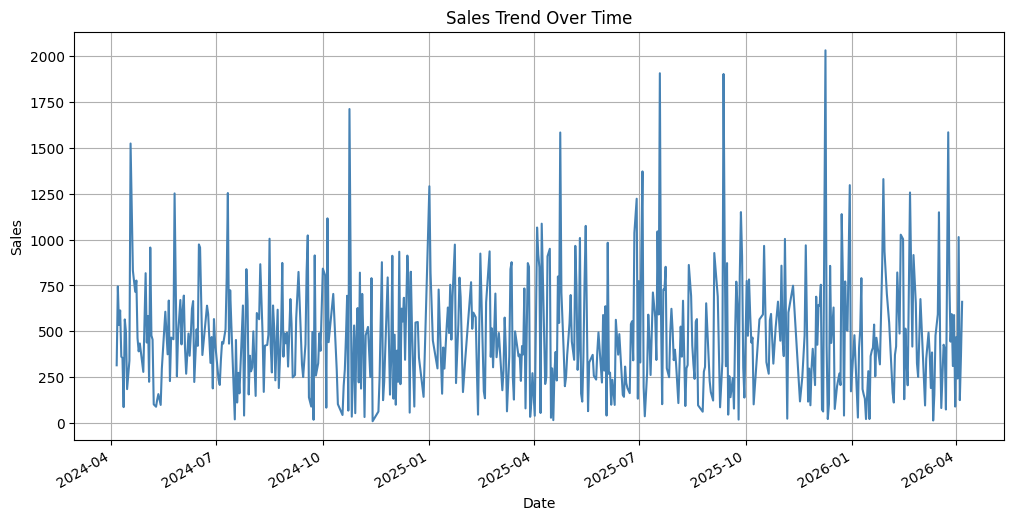

In [9]:
trend = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
trend.plot(color='steelblue')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [10]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly = df.groupby('Month')['Sales'].sum().reset_index()

fig = px.bar(monthly, x='Month', y='Sales', title="Monthly Sales",
             color='Month',
             labels={'Month': 'Month', 'Sales': 'Total Sales'})
fig.update_layout(showlegend=True)
fig.show()

In [11]:
item_sales = df.groupby('Item')['Sales'].sum().reset_index() # Reset index to get Item as a column

fig = px.bar(item_sales, x='Item', y='Sales', title="Sales by Product",
             color='Item',
             labels={'Item': 'Product', 'Sales': 'Total Sales'})
fig.update_layout(showlegend=True)
fig.show()

In [15]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

fig = px.pie(region_sales, values='Sales', names='Region', title="Sales by Region",
             color_discrete_sequence=px.colors.sequential.RdBu)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=True)
fig.show()

/tmp/ipykernel_3973/3815789685.py:6: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



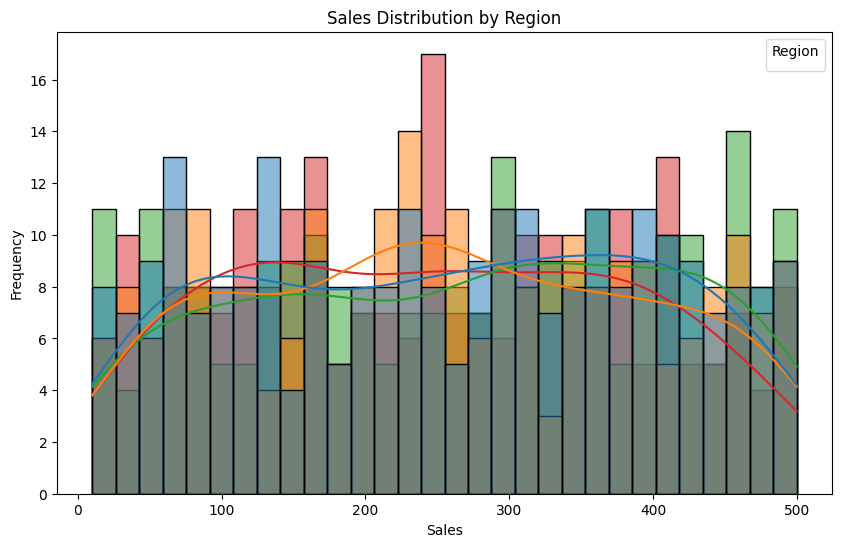

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Sales', hue='Region', bins=30, kde=True)
plt.title("Sales Distribution by Region")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend(title='Region')
plt.show()

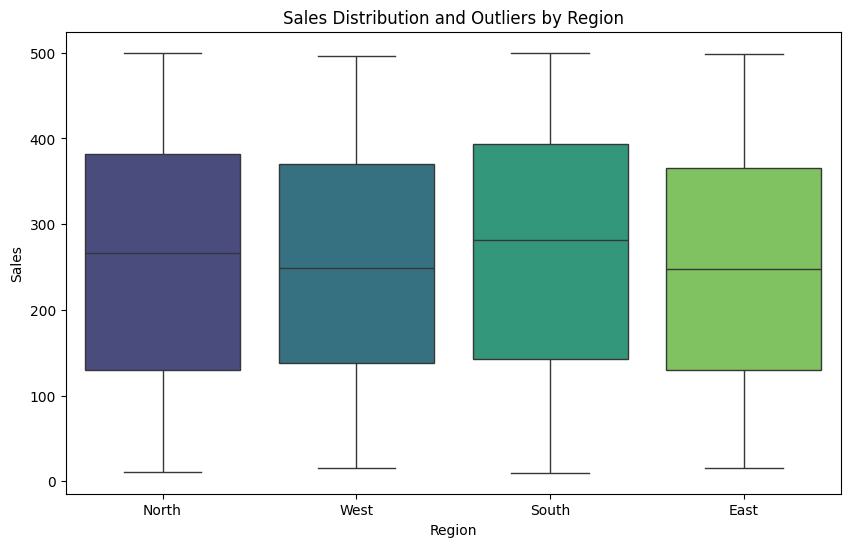

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Region', y='Sales', hue='Region', palette='viridis', legend=False) # Use 'Region' on x-axis and hue for differentiation
plt.title("Sales Distribution and Outliers by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

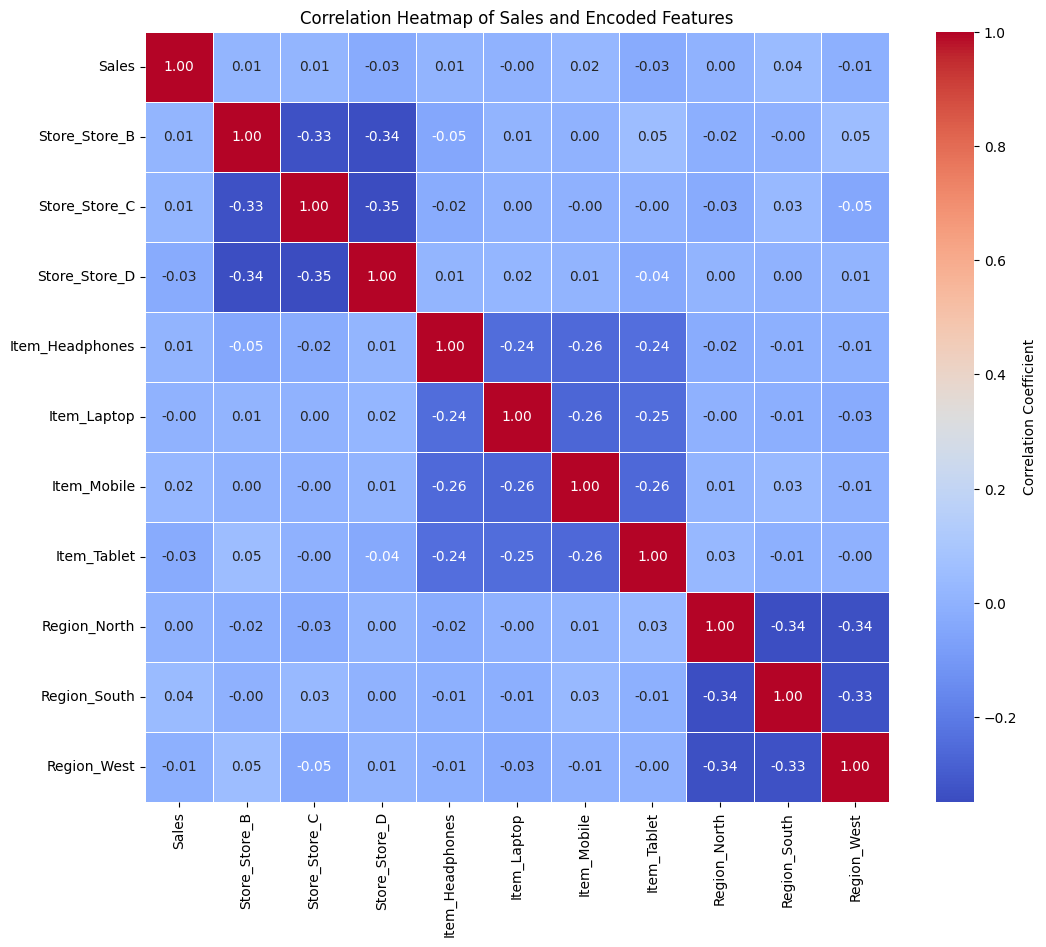

In [20]:
import numpy as np


numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()


categorical_cols = ['Store', 'Item', 'Region']


df_encoded_cat = pd.get_dummies(df[categorical_cols], drop_first=True)


df_for_corr = pd.concat([df[numerical_cols], df_encoded_cat], axis=1)

corr = df_for_corr.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'}) # Use a divergent colormap and label the color bar
plt.title("Correlation Heatmap of Sales and Encoded Features")
plt.show()